## project name: Devali sales data analysis

>#### This is dataset belongs to sales & marketing data analysis catagory
>#### Dataset is made by perplexty AI for real-Market Simulation and analysis
>
>### Now the Problems are:
>
>> - Where majority of products are sold?
>>
>> - Most Sold Product ID?
>>
>> - which are the ideal customers to target?
>> - their Age, Gender, Occupation.




## Libraries Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Loading dataset

In [2]:
df=pd.read_csv("Diwali Sales Data.csv",encoding="unicode_escape")

# step 1: Understanding data

### Data Shape and Columns

In [3]:
df.shape

(11251, 15)

In [4]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='str')

### first 10 columns Info and Description

In [5]:
df.head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [7]:
df.describe

<bound method NDFrame.describe of        User_ID    Cust_name Product_ID Gender Age Group  Age  Marital_Status  \
0      1002903    Sanskriti  P00125942      F     26-35   28               0   
1      1000732       Kartik  P00110942      F     26-35   35               1   
2      1001990        Bindu  P00118542      F     26-35   35               1   
3      1001425       Sudevi  P00237842      M      0-17   16               0   
4      1000588         Joni  P00057942      M     26-35   28               1   
...        ...          ...        ...    ...       ...  ...             ...   
11246  1000695      Manning  P00296942      M     18-25   19               1   
11247  1004089  Reichenbach  P00171342      M     26-35   33               0   
11248  1001209        Oshin  P00201342      F     36-45   40               0   
11249  1004023       Noonan  P00059442      M     36-45   37               0   
11250  1002744      Brumley  P00281742      F     18-25   19               0   

     

# Step 4: DataSet Cleaning 

#### data cleaning steps
    1:fix missing values 
    2:removing duplicates
    3:correcting datatype
    4:cleaning objects (spaces, case issues)

#### applied steps
    1:fix missing values 


> Only deleted 2 coluumns which were filled with null and dropped 12 missing rows 

>> All data Format is correct as it should be
>>
>> - No duplicates 
>> - No format issues
>> - No outliers


In [8]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [9]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df["Amount"]=df["Amount"].astype(int)

# EDA 5.1: Step data visualization


>### customers count by gender

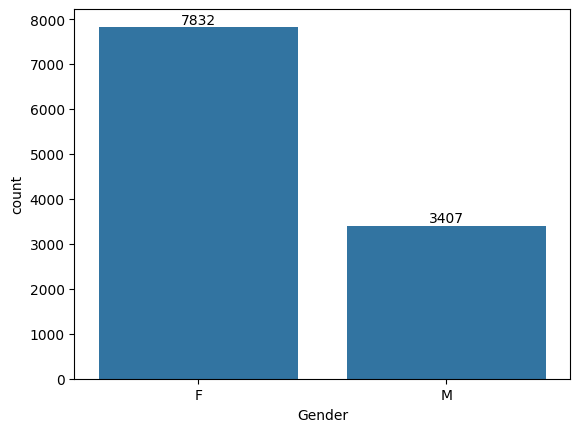

In [12]:
graph=sns.countplot(x='Gender',data=df)
for bars in graph.containers:
    graph.bar_label(bars)

>## result 
> - Univariant analysis
>> - 7832 Females
>> + 3407 Males 
>
> Takeaway from graph: **most buyers are females**

# step 5.3 Univariate data analysis

>## Grouping amount by gender

In [13]:
snsplot=df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

<Axes: xlabel='Gender', ylabel='Amount'>

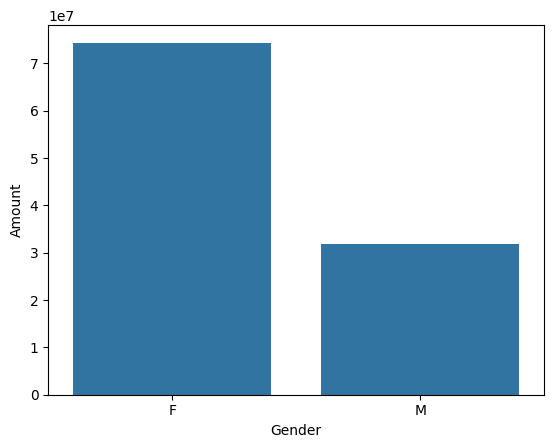

In [14]:
sns.barplot(x="Gender",y="Amount",data=snsplot)

> ## Result of bivariant analysis
>> - Females: 7.3-e7.RS
>>
>> - Males: 3.1-e7.RS
>
>Takeaway from graph: **Females spend more amount of money on shopping than males**

># Plotting count of age group by Gender

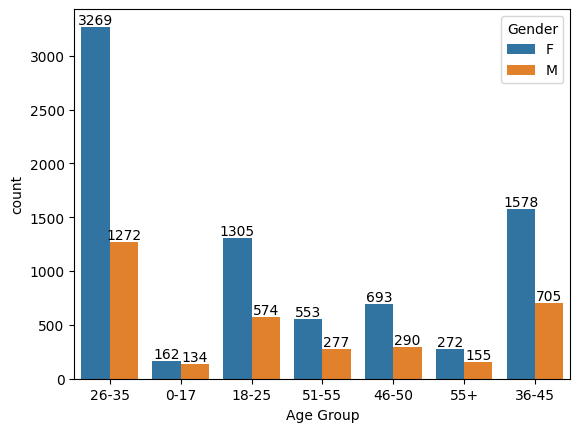

In [15]:
graph=sns.countplot(data=df,x="Age Group",hue="Gender")
for bars in graph.containers:
    graph.bar_label(bars)

>## Result of by bivariant analysis 
>
>> takeaway from graph: Females of age group 26-35 are majority purchasing and age group 0-17 is the least purchasing group

>## plotting of age group by amount 

<Axes: xlabel='Age Group', ylabel='Amount'>

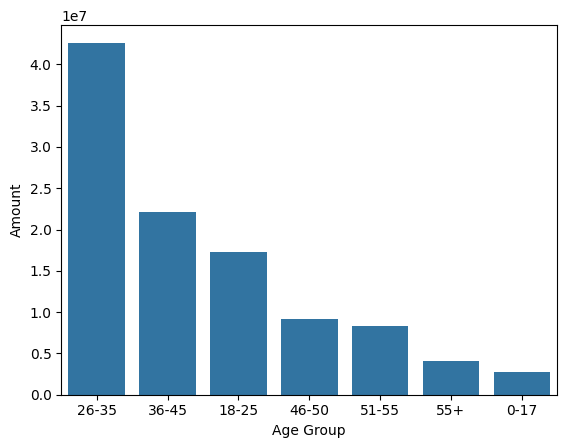

In [16]:
gOfSa=df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(x='Age Group',y='Amount',data=gOfSa)

># Result of bivariant analysis
>
># From above graph we can conclude that:
>> **Age group 26-35 have the most purhasing power**

>## Grouping of Orders by Top 10 States

<Axes: xlabel='State', ylabel='Orders'>

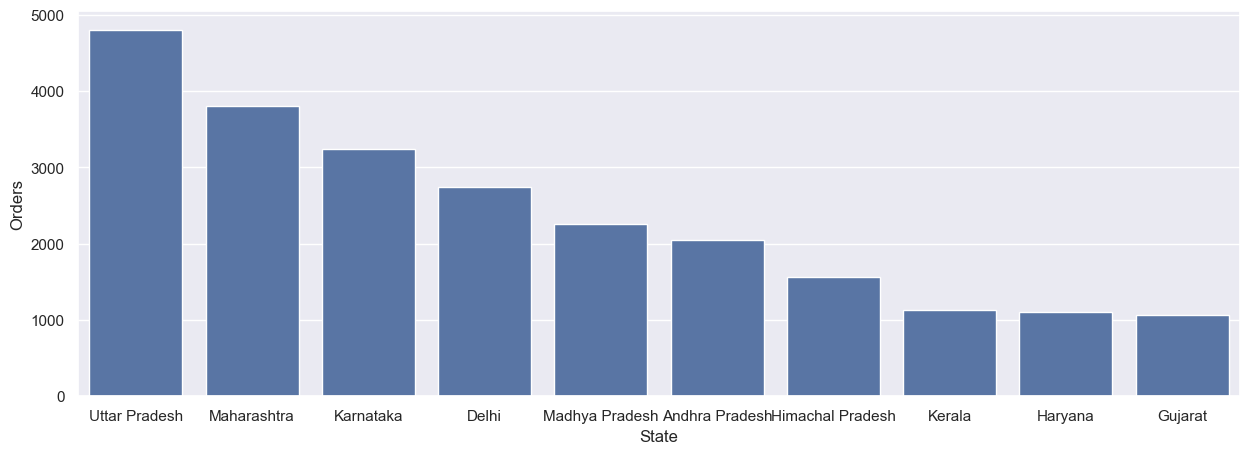

In [17]:
#total amount from states
SalesAreas=df.groupby(['State'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
#above code of line is not important it's only used to space graph
sns.barplot(x='State',y='Orders',data=SalesAreas)

># Result of bivariant analysis:
>> Most orders are from **Utter pradesh, Maharashtra, Karnataka and Delhi**

>## Grouping of Amount of Rupees by Top 10 States

<Axes: xlabel='State', ylabel='Amount'>

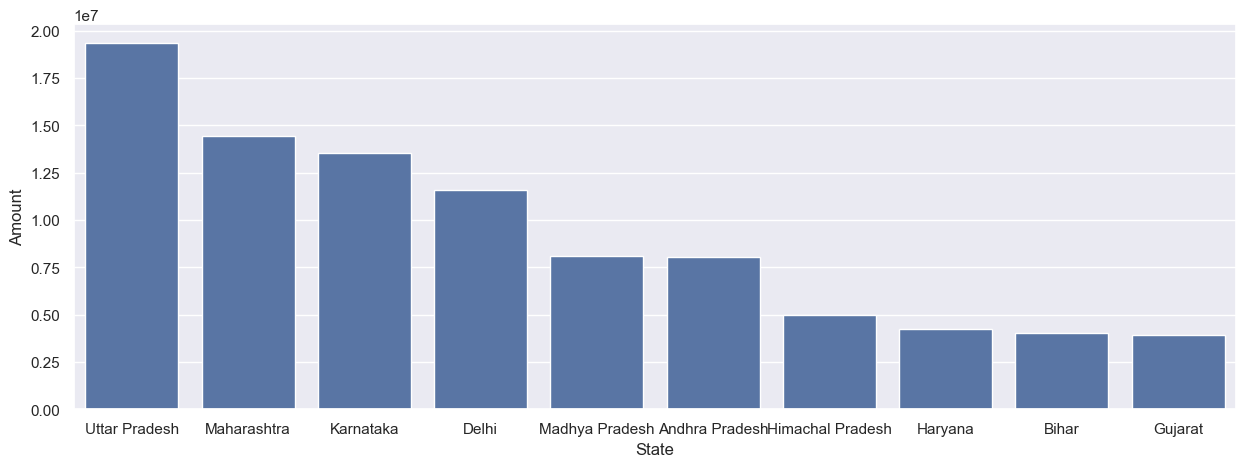

In [18]:
SalesAreas=df.groupby(['State'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False).head(10)
sns.barplot(x='State',y='Amount',data=SalesAreas)

># Result of bivariant analysis:
>> Most spending states are also **Utter pradesh, Maharashtra, Karnataka and Delhi**

>## counting Customers by maritial status

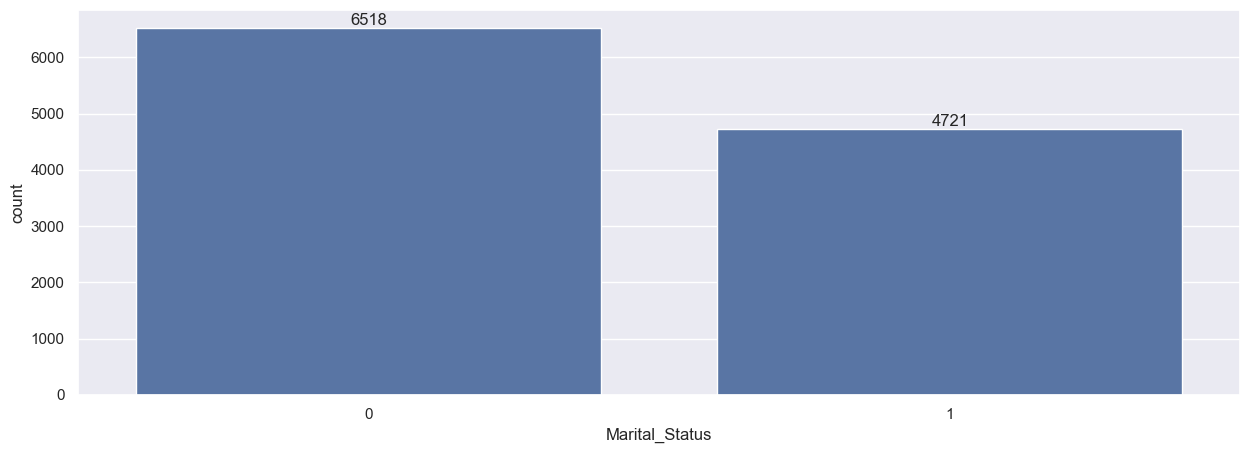

In [19]:
graph=sns.countplot(data=df,x='Marital_Status')
sns.set(rc={'figure.figsize':(3,5)})
for counts in graph.containers:
    graph.bar_label(counts)

># Result of univariant analysis:
>> 57% of our customers are **single**

># Grouping sale amount by marital status and gender

In [20]:
saleByMaritalState=df.groupby(['Marital_Status','Gender'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)

<Axes: xlabel='Marital_Status', ylabel='Amount'>

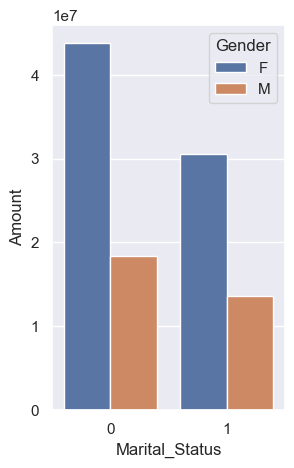

In [21]:
sns.barplot(data=saleByMaritalState,x='Marital_Status',y='Amount',hue='Gender')

># Result of Multivariant:
>> **Single females are the most spending group**

>## Graph 1;
>>#### Grouping sale amount by Occpation and Marital status.
>## Graph 2;
>>#### and Grouping Order Qty by Occpation and Gender.

<Axes: xlabel='Occupation', ylabel='Amount'>

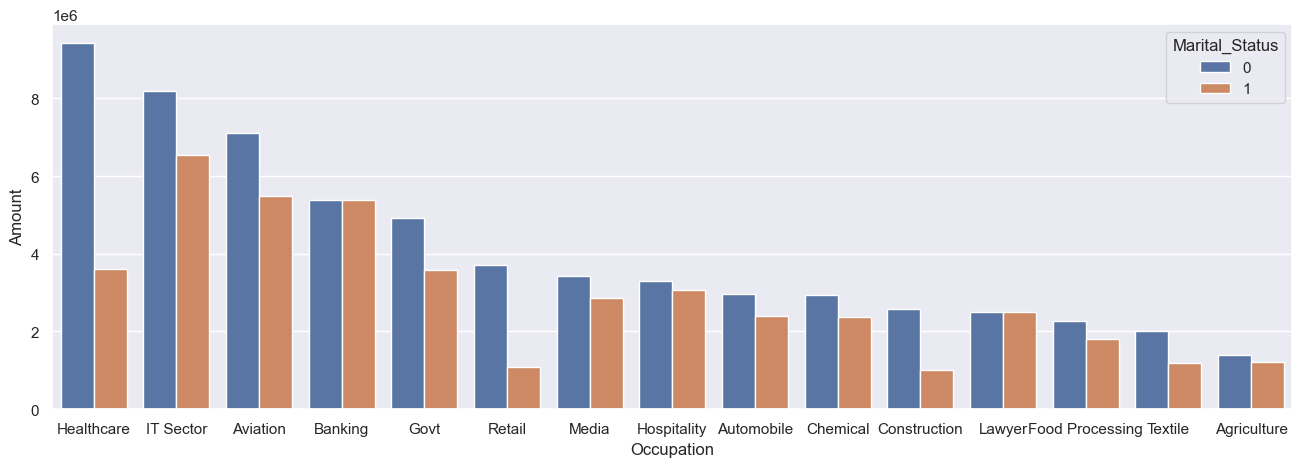

In [22]:
#saleAmount by occupation and marital status
saleAmountByOccNgender=df.groupby(['Occupation','Marital_Status'],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.set(rc={'figure.figsize':(16,5)})
sns.barplot(data=saleAmountByOccNgender,x='Occupation',y='Amount',hue='Marital_Status')

<Axes: xlabel='Occupation', ylabel='Orders'>

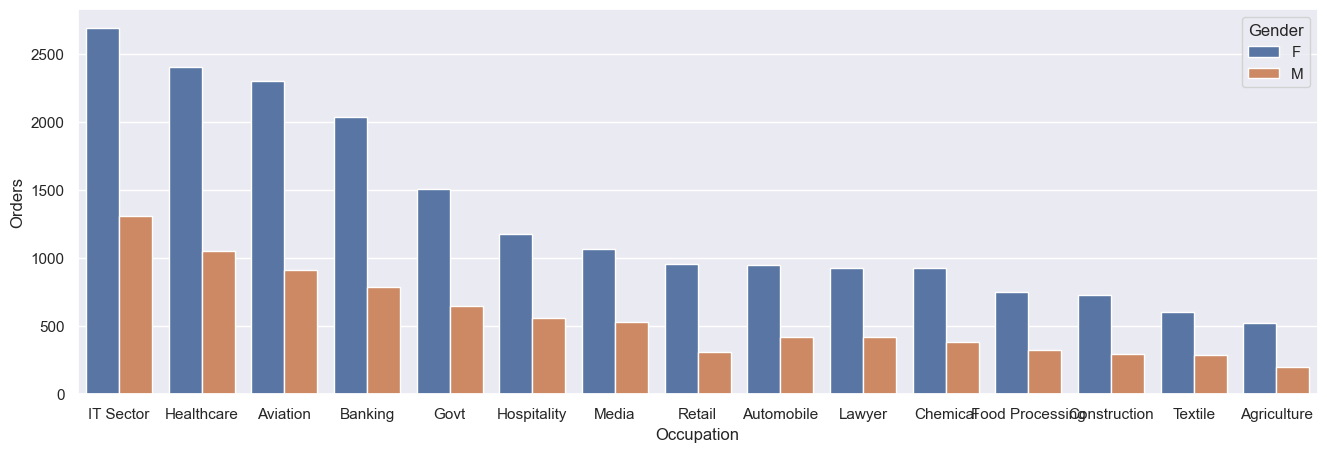

In [23]:
#OrdersQty by occupation and gender
ordersByOccNgender=df.groupby(['Occupation','Gender'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False)
sns.barplot(data=ordersByOccNgender,x='Occupation',y='Orders',hue='Gender')

># Result of 2 graphs multivariant analysis:
>>## Graph 1:
>>>#### Sale Amount is dominated by singles working in IT Sector, Healthcare and Avation 
>>
>>## Graph 2:
>>>#### Quantity is dominated by females working in IT Sector, Healthcare and Avation

># analyzing product categories

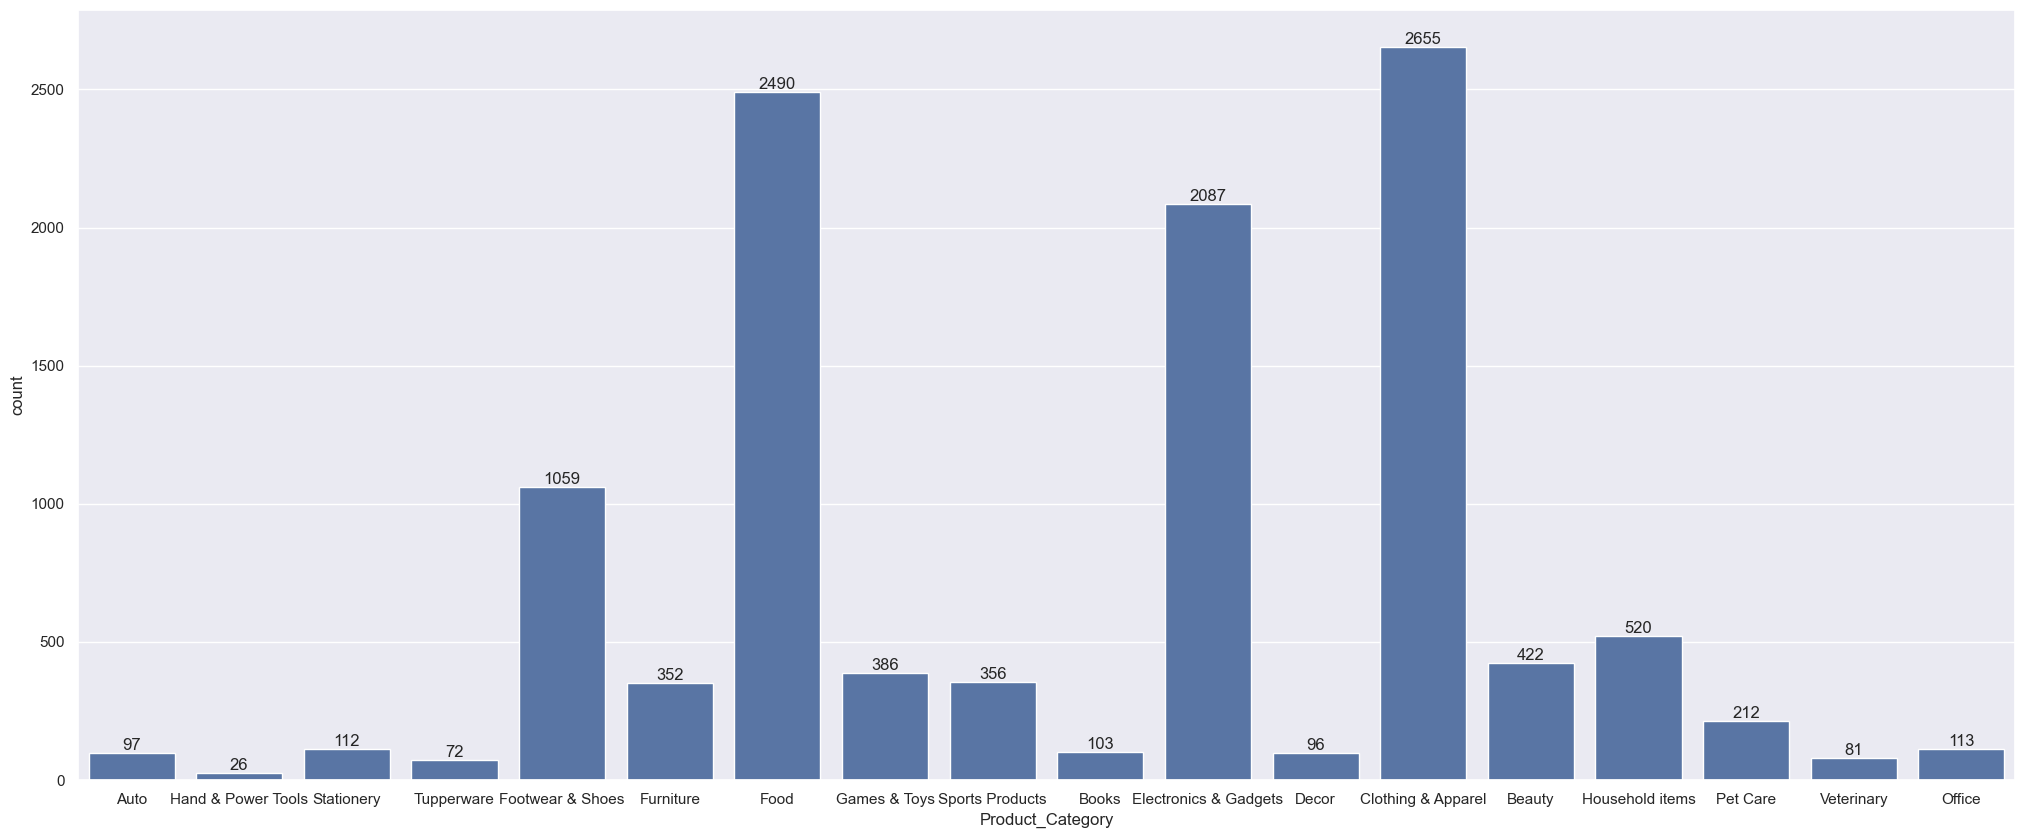

In [24]:
sns.set(rc={'figure.figsize':(25,10)})
graph=sns.countplot(data=df,x='Product_Category')
for count in graph.containers:
    graph.bar_label(count)


>## Result of Univariant analysis
>> Most bought product categories are **Clothing & Apparel, Food, Electronic & Gadgets and Footwear & Shoes**

### ONLY FOR ADDITIONAL DATA AND STATISTICS
>##### Analysis of SaleAmount by ProdCategories, Gender, MartStatus
>##### Analysis of OrderQty by ProdCategories, Gender, MartStatus


<Axes: xlabel='Product_Category', ylabel='Amount'>

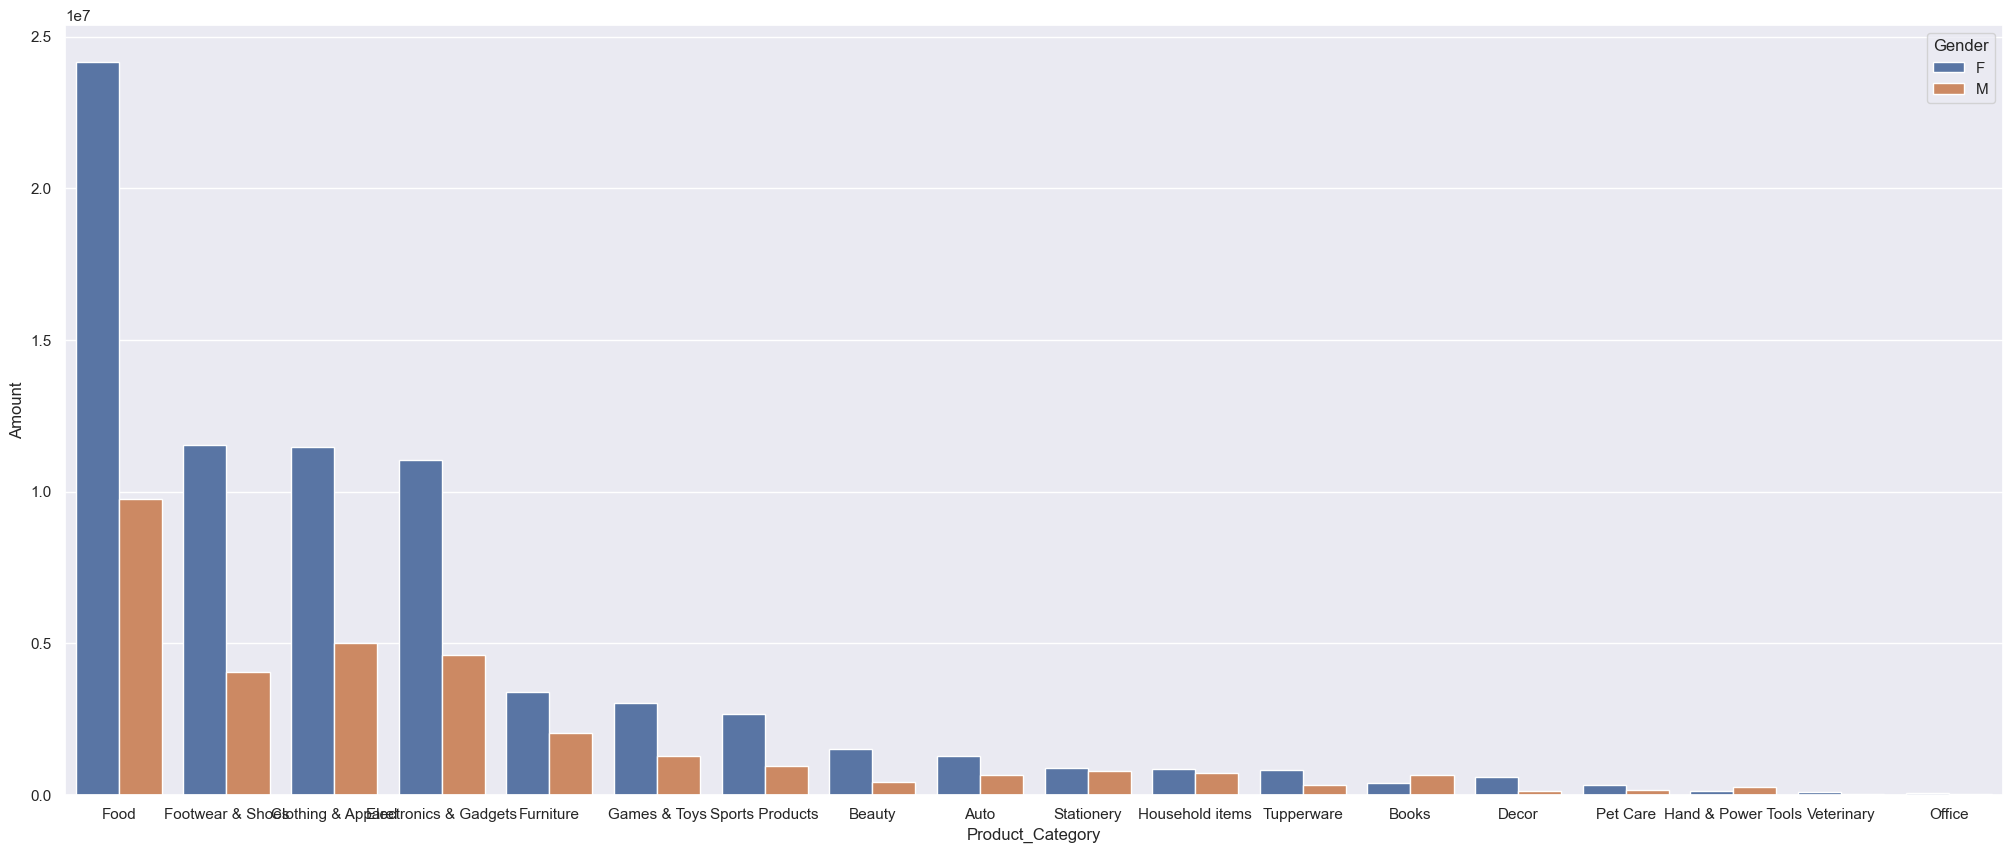

In [25]:
saleAmoprod=df.groupby(['Product_Category','Gender',],as_index=False)['Amount'].sum().sort_values(by='Amount',ascending=False)
sns.barplot(data=saleAmoprod,x='Product_Category',y='Amount',hue='Gender')

<Axes: xlabel='Product_Category', ylabel='Orders'>

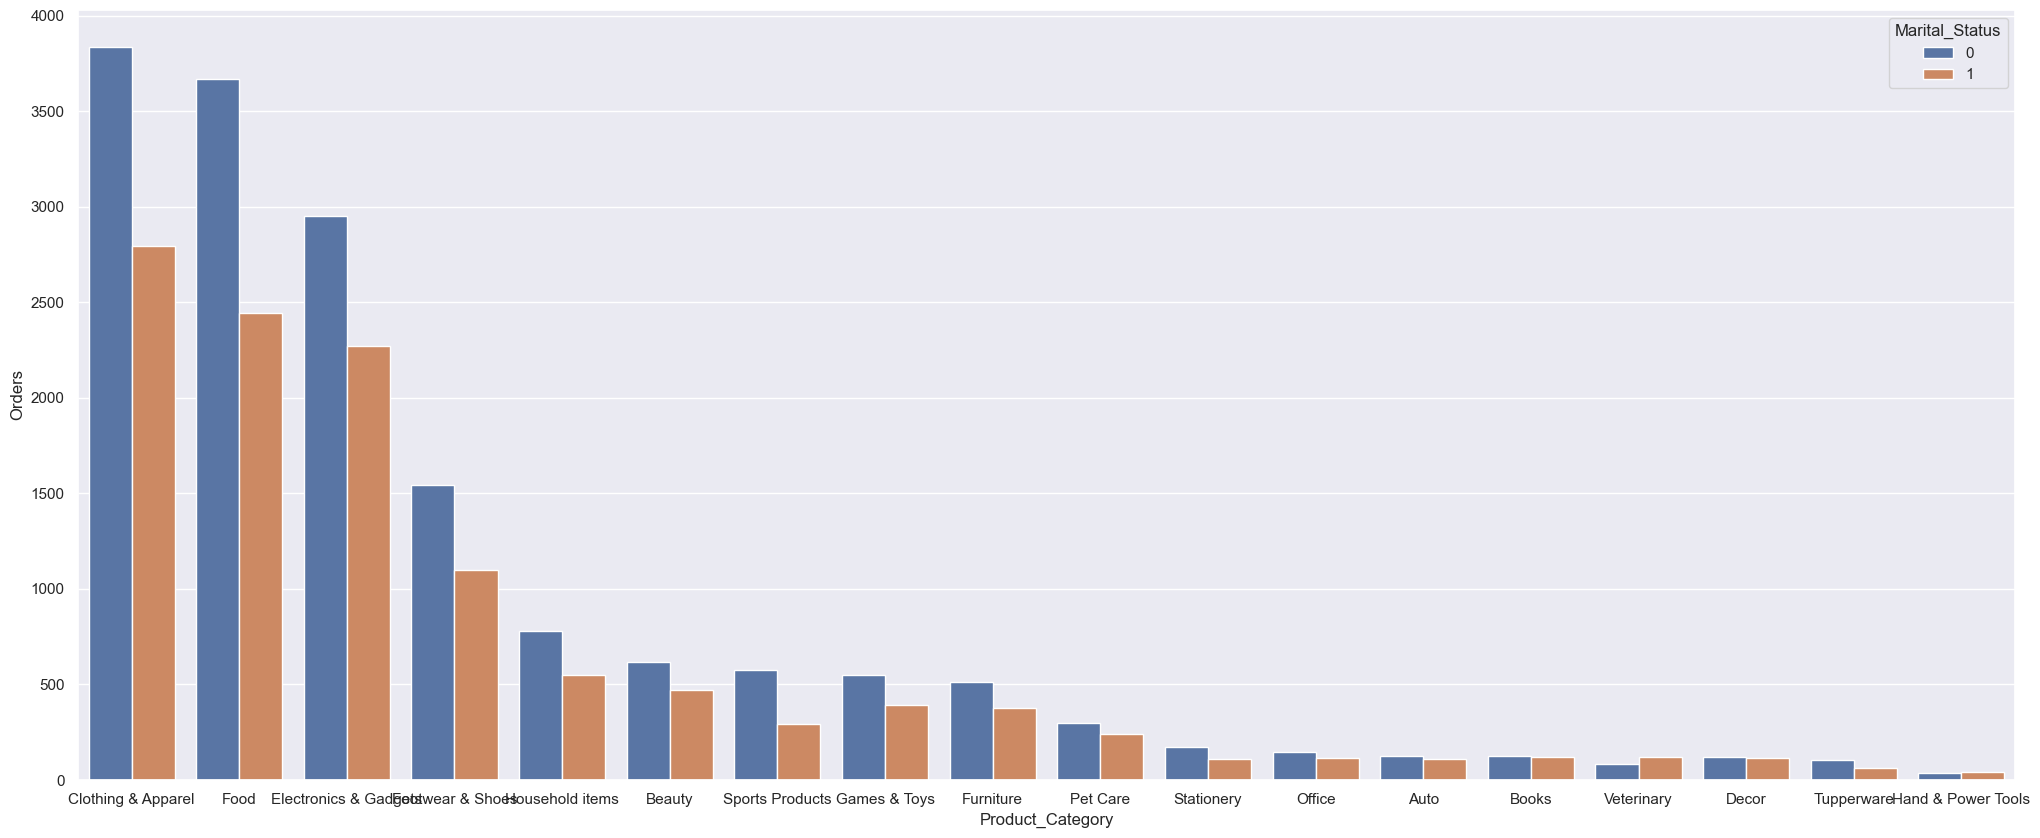

In [32]:
saleQtyProd=df.groupby(['Product_Category','Marital_Status'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False)
sns.barplot(data=saleQtyProd,x='Product_Category',y='Orders',hue='Marital_Status')

># Top 10 most bought products IDs

<Axes: xlabel='Product_ID', ylabel='Orders'>

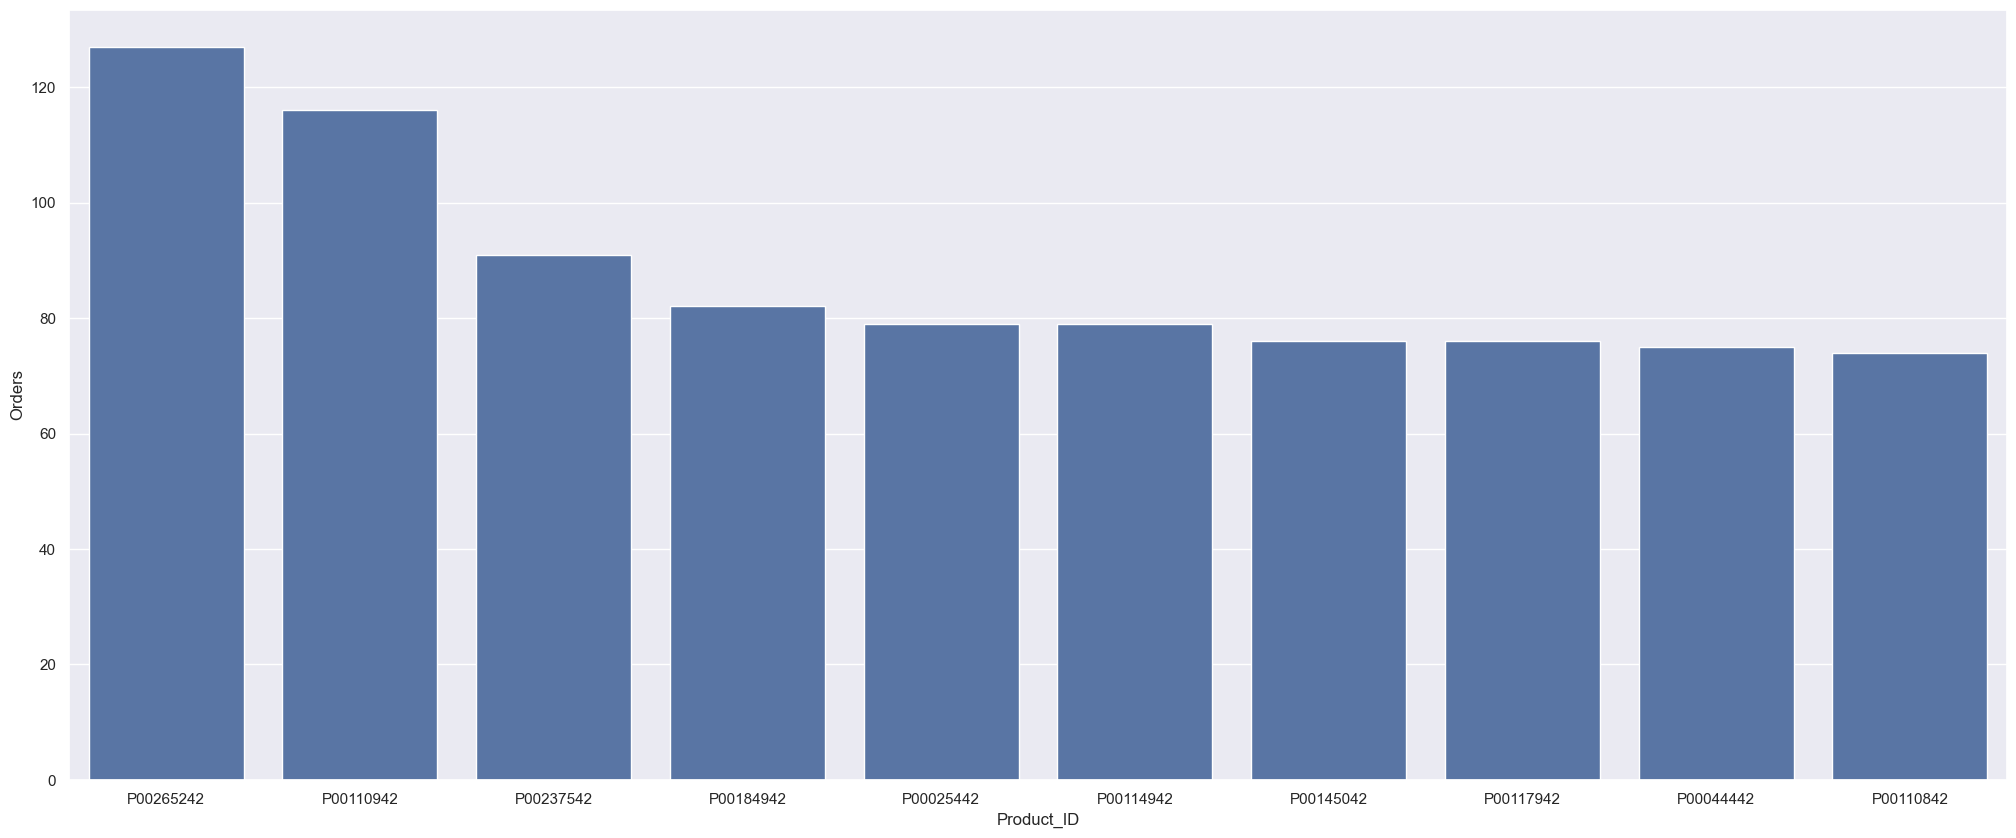

In [27]:
saleItem=df.groupby(['Product_ID'],as_index=False)['Orders'].sum().sort_values(by='Orders',ascending=False).head(10)
sns.barplot(data=saleItem,x='Product_ID',y='Orders')

#### EDA Steps 3, 4 are missing because there was no need to Identify outliers and Transform data.
> - No outliers found
>
> - Data Already Structured


## Step 6 Conclusion / Insights

>1:Data imported 
>
>step 2..EDA 1 :Statistical data analysis
>
>3:Data cleaned
>>- Deleted missing columns
>>- Removed missing values
>
>step 4..EDA 2 :Data Visualization
>>- Perfomed univariant analysis
>>- Performed bivariant analysis
>>- performed multivariant analysis
>
>

## Step 6 Conclusion / Insights

The business lacked a granular understanding of its primary revenue drivers. Generic marketing strategies were resulting in suboptimal engagement, as the company could not clearly distinguish between high-value customer segments and low-interaction groups.


By mapping the intersection of purchasing power and demographic profile, I developed a prioritized customer persona (Single females, 26–35, working in IT/Healthcare/Aviation). This allows the business to transition from mass-market advertising to targeted, high-conversion campaigns that specifically address the preferences of this high-value cohort.


>Core Data Insights
>>- High-Value Demographic: The 26–35 age bracket holds the highest purchasing power
>>marketing ROI will be maximized by focusing exclusively on this segment.
>>
>>- Professional Alignment: The concentration of sales in the IT, Healthcare, and Aviation
>>- sectors suggests a need for industry-specific promotional content.
>>
>>- Geographic Concentration: With major activity in UP, Maharashtra, Karnataka, and 
>>Delhi, logistics and regional ad spend should be optimized to these specific 
>>high-density hubs.
>>
>>- The "Single" Factor: Since 57% of customers are single and represent the highest 
>>spenders, loyalty programs and product bundles should be tailored to individual-use 
>>cases rather than household/family-centric consumption.
>>
>>- Category Synergy: Cross-promoting Electronics and Apparel will capture the largest 
>>share of wallet from your primary target audience.
